##### AI Usage Disclosure:
I did this project with some help from AI tools like ChatGPT to make learning and getting things done easier. I used AI for a things:
- Getting help with writing code and figuring out the right syntax
- Thinking about how to make models and workflows work
- Understanding new ideas and ways of doing things that I read about in a research paper
- Writing the first versions of introductions to sections and organizing my explanations

But I made all the important decisions about how to do things developed the models prepared the data and figured out what the results meant on my own. I used AI as a tool to help me not to do the work for me. I tried hard to make sure that the final code, analysis and conclusions are really mine and show that I understand the project and the ideas, behind it.

## Reproducibility in Data Science: A Data Ethics Project

### Project Overview:  This project examines reproducibility in data science by attempting to replicate results from a published paper. Groups will document challenges, variations in results, and missing information while considering the ethical implications of reproducibility issues.

- Paper Link: https://arxiv.org/pdf/2407.00890

- Dataset Link: https://www.stlouisfed.org/research/economists/mccracken/fred-databases

### Introduction about the paper:

This project is about looking at the paper `Macroeconomic Forecasting with Large Language Models` and seeing what we can learn from it. The paper tries to figure out if modern computer models can do a job of predicting what will happen with the economy than traditional methods.

The paper uses a set of data called FRED-MD, which has a lot of information about the United States economy including things like how many people are working how much things cost and how much money is being borrowed. The main goal is to see how well different models can predict what these economic indicators will be in the future.

One important thing the paper does is compare two types of models:

- The way of doing things with statistics like using Autoregressive models Bayesian VAR and factor models

- Newer computer models and large language models that are good at predicting what will happen next in a series of events

To make the test fair the paper uses a method where the models are retrained every time new data comes in. Then it looks at how each model did by using something called Root Mean Squared Forecast Error.

In our project we want to do the thing as the paper by:

- Using the same set of data, which is FRED-MD

- Building simple and more complicated models, like Autoregressive and VAR

- Trying out two different ways to test the models, one where the data does not change and one where it does

- Comparing how well the models do by using two types of measurements, RMSE and RMSFE

We had to make some changes because we did not have all the information we needed and our computers were not powerful enough. So we used a set of data and did some standard things to get the data ready.

The point of this project is not to get the same results, as the original paper but to understand how the models work see how they do in different situations and think about the challenges of repeating the results of other peoples work in the field of data science.

### Project Goals:
- Attempt to reproduce key results from the selected paper
- Document all challenges and deviations
- Analyze implications for scientific integrity
- Propose best practices for reproducible research
- Create a fully reproducible version of your work

### Section 1: Importing all the required libraries

- Import all required Python libraries for data processing, visualization, and modeling
- Set up the environment for time series analysis
- Ensure reproducibility by using consistent library imports

In [ ]:
#Data handling
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

# Time Series Models
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Section 2: Load the required datasets

- Load the FRED-MD dataset into the notebook
- Inspect the structure and format of the dataset
- Identify key variables and understand the data layout

In [ ]:
#Load dataset
df = pd.read_csv("data/2026-02-MD.csv")

#Basic info
print("Shape of dataset:", df.shape)

#Column names
print("\nColumns:\n", df.columns.tolist())

df.head()

Shape of dataset: (806, 127)

Columns:
 ['sasdate', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'IPFUELS', 'CUMFNS', 'HWI', 'HWIURATIO', 'CLF16OV', 'CE16OV', 'UNRATE', 'UEMPMEAN', 'UEMPLT5', 'UEMP5TO14', 'UEMP15OV', 'UEMP15T26', 'UEMP27OV', 'CLAIMSx', 'PAYEMS', 'USGOOD', 'CES1021000001', 'USCONS', 'MANEMP', 'DMANEMP', 'NDMANEMP', 'SRVPRD', 'USTPU', 'USWTRADE', 'USTRADE', 'USFIRE', 'USGOVT', 'CES0600000007', 'AWOTMAN', 'AWHMAN', 'HOUST', 'HOUSTNE', 'HOUSTMW', 'HOUSTS', 'HOUSTW', 'PERMIT', 'PERMITNE', 'PERMITMW', 'PERMITS', 'PERMITW', 'ACOGNO', 'AMDMNOx', 'ANDENOx', 'AMDMUOx', 'BUSINVx', 'ISRATIOx', 'M1SL', 'M2SL', 'M2REAL', 'BOGMBASE', 'TOTRESNS', 'NONBORRES', 'BUSLOANS', 'REALLN', 'NONREVSL', 'CONSPI', 'S&P 500', 'S&P div yield', 'S&P PE ratio', 'FEDFUNDS', 'CP3Mx', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'COMPAPFFx', 'TB3SM

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,Transform:,5.000,5.0,5.000,5.0000,5.00000,5.0000,5.0000,5.0000,5.0000,...,6.000,6.000,6.00,6.00,6.00,2.0,6.0,6.0,6.0000,1.0
1,1/1/1959,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,283362.7075,17978.97983,23.2384,24.4431,23.1926,32.8841,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN


In [ ]:
#Remove first row (transformation codes)
df = df.iloc[1:].copy()

# Rename 'sasdate' to 'date'
df.rename(columns={'sasdate': 'date'}, inplace=True)

#Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

#set date as index
df.set_index('date', inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

#Check result
print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (805, 126)


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,19.7514,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
1959-02-01,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,19.8551,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
1959-03-01,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,20.2439,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
1959-04-01,2627.446,2470.0,15.435,283362.7075,17978.97983,23.2384,24.4431,23.1926,32.8841,20.3735,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN
1959-05-01,2642.720,2486.4,15.622,285307.2201,18119.82573,23.5885,24.6460,23.4159,33.0413,20.7882,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.0,12646.0,80.7315,NaN


### Section 3: Exploratory Data Analysis

- Clean the dataset by removing transformation metadata
- Handle missing values using interpolation and filling techniques
- Analyze the dataset structure and prepare it for modeling

In [ ]:
#Count missing values per column
missing_counts = df.isna().sum()

#Show columns with missing values
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Columns with missing values:\n")
print(missing_counts.head(20))  # show top 20

print("\nTotal columns with missing values:", len(missing_counts))

Columns with missing values:

ACOGNO             398
TWEXAFEGSMTHx      168
UMCSENTx           154
ANDENOx            110
VIXCLSx             42
PERMIT              13
PERMITW             13
PERMITS             13
PERMITMW            13
PERMITNE            13
S&P PE ratio         3
ISRATIOx             2
BUSINVx              2
CMRMTSPLx            2
HWIURATIO            2
CUSR0000SA0L5        1
DNDGRG3M086SBEA      1
CP3Mx                1
COMPAPFFx            1
DTCTHFNM             1
dtype: int64

Total columns with missing values: 58


In [ ]:
#Drop columns with more than 20% missing values
threshold = int(0.2 * len(df))
df = df.dropna(axis=1, thresh=len(df) - threshold)

print("Shape after dropping high-missing columns:", df.shape)

#Interpolate remaining missing values
df = df.interpolate(method='linear')

# Final check
print("\nRemaining missing values:", df.isna().sum().sum())

Shape after dropping high-missing columns: (805, 124)

Remaining missing values: 215


In [ ]:
#fill remaining missing values
df = df.fillna(method='ffill').fillna(method='bfill')

#Final check
print("Remaining missing values after full cleaning:", df.isna().sum().sum())

Remaining missing values after full cleaning: 0


#### Section Summary:
- The Exploratory Data Analysis (EDA) phase concentrated on preparing the FRED-MD dataset for upcoming modeling work.

- The dataset included transformation metadata which appeared as the first row therefore we deleted this row to conduct our analyses using only numerical data.

- The dataset contained multiple variables which had numerous missing values. So, these were treated by:
    - Column removal for variables with excessive missing values
    - Linear interpolation for internal gaps
    - Forward and backward filling for boundary values

- Preprocessing completed its task because it delivered a complete dataset which researchers could use for time series modeling.

- The main problem in this process occurred because the original research paper failed to present its complete data preprocessing methods.

- The missing value treatment process and the actual transformation codes plus data cleanup methods remained undisclosed.

- We needed to establish certain assumptions which resulted in different outcomes. The research shows that even tiny variations in data preprocessing work lead to huge changes in how models perform.

### Section 4: Interpretation of Variables

To get a grasp of forecasting we looked at a few important economic indicators. These include production, inflation, unemployment rate, federal funds rate and total employment.

These indicators cover parts of the economy:

- **Industrial Production:** This shows how much industry is producing. It helps us understand the economys activity.

- **Inflation:** This measures how much prices are rising. It affects the cost of living.

- **Unemployment Rate:** This tells us about the job market.

- **Federal Funds Rate:** This is about the interest rate. It shows us the banks policy on borrowing money.

- **Total Employment:** This shows how many people have jobs. It tells us about job growth and the economys expansion.

The VAR model tries to understand how these indicators relate to each other. For instance:

- When interest rates change it can affect inflation and employment.

- Industrial production often grows when there are jobs and the economy is doing well.

- When people are unemployed it usually means the economy is not doing well.

Because we are using fewer indicators in this project it might not fully show how the economy works. The original study used, over 100 indicators.

#### Reproducing the Results:

The original study looked at more indicators. This helped it understand the economy better. By using indicators this reproduction makes the economy simpler. This might make it harder for the model to understand how different parts of the economy interact.

This also shows another side of reproducing results: it's not just hard to copy models but making things simpler can also affect how well the results make sense and how realistic they are.

### Section 5: Baseline Model (AR)

- Implement a univariate Autoregressive (AR) model as a baseline
- Generate predictions for the target variable
- Evaluate model performance using RMSE

In [ ]:
#Initialize scaler
scaler = StandardScaler()

#Fit and transform data
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    index=df.index,
    columns=df.columns
)

#Check result
df_scaled.head()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,-1.373714,-1.421085,-1.347337,-1.425545,-1.069197,-1.721630,-1.818867,-1.799052,-2.078649,-1.717672,...,-1.447132,-1.270150,-1.317767,-1.362847,-1.343117,0.762157,-0.932942,-1.023738,-0.842924,0.039471
1959-02-01,-1.371792,-1.418954,-1.342340,-1.420360,-1.068533,-1.705578,-1.807023,-1.791868,-2.068439,-1.714024,...,-1.446880,-1.269726,-1.316562,-1.361775,-1.341773,0.762157,-0.932942,-1.023738,-0.843355,0.039471
1959-03-01,-1.368574,-1.414620,-1.337755,-1.422750,-1.067772,-1.693535,-1.801638,-1.787765,-2.068439,-1.700347,...,-1.447290,-1.269218,-1.315357,-1.362847,-1.339084,0.762157,-0.932728,-1.023589,-0.844558,0.039471
1959-04-01,-1.365309,-1.410431,-1.339526,-1.408528,-1.067715,-1.675479,-1.788714,-1.775451,-2.046317,-1.695788,...,-1.446943,-1.268202,-1.314152,-1.360703,-1.337740,0.762157,-0.931980,-1.023197,-0.844450,0.039471
1959-05-01,-1.362383,-1.406460,-1.333612,-1.403578,-1.066995,-1.662434,-1.781178,-1.767241,-2.039507,-1.681199,...,-1.447574,-1.267722,-1.312947,-1.359630,-1.337740,0.762157,-0.931091,-1.022726,-0.845137,0.039471


In [ ]:
#Split data(just like paper-train early, test later)

train_size = int(len(df_scaled) * 0.8)

train = df_scaled.iloc[:train_size]
test = df_scaled.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (644, 124)
Test shape: (161, 124)


In [ ]:
#Select one variable
target_col = 'INDPRO'

#Train model
model = AutoReg(train[target_col], lags=1).fit()

#predict on test set
predictions = model.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

#Convert to pandas series
predictions = pd.Series(predictions, index=test.index)

#Compare actual vs predicted
result_df = pd.DataFrame({
    'Actual': test[target_col],
    'Predicted': predictions
})

result_df.head()

,Actual,Predicted
date,,
2012-09-01,1.087129,1.093771
2012-10-01,1.099734,1.097747
2012-11-01,1.113088,1.101723
2012-12-01,1.121748,1.105697
2013-01-01,1.122646,1.109671


In [ ]:
#Calculate RMSE
rmse = np.sqrt(mean_squared_error(result_df['Actual'], result_df['Predicted']))

print("AR Model RMSE:", rmse)

AR Model RMSE: 0.2919885557151135


#### Section Summary:

- We used a model that looks at past numbers of one thing called `INDPRO` to guess what the future numbers will be. This is called an Autoregressive model.

- We wanted to see how good our model was at guessing the numbers. To do this we used something called Root Mean Squared Error. This is like a report card for our model. It shows us how far off our guesses were from the numbers.

- The score we got was 0.292.

This gives us a baseline to compare models to.

#### Reproducibility Insight: 

- Our model is easy to understand and copy because it is simple and does not make a lot of assumptions. It also does not need a lot of adjustments to work well.

- This is a point: simple models like ours are often easy to copy and work well as a starting point for other studies. The `INDPRO` model we used is an example of this. Simple models, like the `INDPRO` model are good to use when we want to be sure our results are real and not just because of a model.

### Section 6: Multivariate Model (VAR)

- Build a Vector Autoregression (VAR) model using multiple variables
- Select optimal lag length using statistical criteria
- Compare VAR performance with the baseline AR model

In [14]:
# Select a subset of variables for VAR
selected_cols = ['INDPRO', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'PAYEMS']

train_var = train[selected_cols]
test_var = test[selected_cols]

print("Train VAR shape:", train_var.shape)
train_var.head()

Train VAR shape: (644, 5)


,INDPRO,CPIAUCSL,UNRATE,FEDFUNDS,PAYEMS
date,,,,,
1959-01-01,-1.721630,-1.310564,0.086095,-0.636979,-1.758233
1959-02-01,-1.705578,-1.310680,0.026681,-0.650905,-1.751592
1959-03-01,-1.693535,-1.311029,-0.151562,-0.547848,-1.741283
1959-04-01,-1.675479,-1.310913,-0.389220,-0.503283,-1.731574
1959-05-01,-1.662434,-1.310216,-0.448634,-0.519995,-1.724332


In [15]:
# Fit VAR model for lag selection
model = VAR(train_var)

# Select optimal lag
lag_results = model.select_order(maxlags=10)

print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.199      -9.164   0.0001012      -9.185
1       -38.16      -37.95   2.676e-17      -38.08
2       -39.14      -38.75   1.005e-17      -38.99
3       -39.44     -38.88*   7.438e-18     -39.22*
4       -39.46      -38.73   7.266e-18      -39.18
5       -39.47      -38.55   7.238e-18      -39.11
6      -39.51*      -38.42  6.965e-18*      -39.08
7       -39.48      -38.22   7.124e-18      -38.99
8       -39.47      -38.03   7.204e-18      -38.91
9       -39.48      -37.87   7.142e-18      -38.85
10      -39.46      -37.67   7.316e-18      -38.76
--------------------------------------------------


In [16]:
# Fit VAR model with selected lag
var_model = VAR(train_var)
var_results = var_model.fit(3)

print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     00:51:09
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -38.8816
Nobs:                     641.000    HQIC:                  -39.2224
Log likelihood:           8172.37    FPE:                7.44837e-18
AIC:                     -39.4386    Det(Omega_mle):     6.58453e-18
--------------------------------------------------------------------
Results for equation INDPRO
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.000977         0.001189           -0.821           0.412
L1.INDPRO           1.047890         0.045235           23.165           0.000
L1.CPIAUCSL         0.631383         0.162761            3.879     

In [17]:
# Get last lag observations from training data
lag_order = var_results.k_ar
forecast_input = train_var.values[-lag_order:]

# Forecast
forecast = var_results.forecast(
    y=forecast_input,
    steps=len(test_var)
)

# Convert to DataFrame
forecast_df = pd.DataFrame(
    forecast,
    index=test_var.index,
    columns=test_var.columns
)

forecast_df.head()

,INDPRO,CPIAUCSL,UNRATE,FEDFUNDS,PAYEMS
date,,,,,
2012-09-01,1.104252,1.032783,1.314000,-1.293774,0.833627
2012-10-01,1.110345,1.036488,1.274964,-1.317814,0.837457
2012-11-01,1.115460,1.039398,1.240953,-1.344109,0.839799
2012-12-01,1.119838,1.042696,1.215639,-1.368478,0.842088
2013-01-01,1.124211,1.046327,1.195519,-1.391893,0.843778


In [18]:
# Extract VAR predictions for INDPRO
var_pred = forecast_df['INDPRO']

# Actual values
actual = test_var['INDPRO']

# Calculate VAR RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

var_rmse = np.sqrt(mean_squared_error(actual, var_pred))

print("AR RMSE:", rmse)
print("VAR RMSE:", var_rmse)

AR RMSE: 0.2919885557151135
VAR RMSE: 0.17046326124995245


#### Section Summary:

- We used a Vector Autoregression model to see how different macroeconomic variables affect each other. We had to pick a few variables because our computer was not powerful enough to handle all of them.

- Our Vector Autoregression model looked at what happened three times to make predictions. We chose to look three times because it seemed to work best according to some tests we did. We then checked to see how well our Vector Autoregression model was working by using something called RMSE:

- The Vector Autoregression model RMSE was 0.170

- The Autoregression model RMSE was 0.292

- When we split our data into two parts to test our Vector Autoregression model it did better than the Autoregression model. This means that using variables to make predictions is a good idea.

#### Reproducibility Insight:

- We did not use all the data we had because our computer was not powerful enough. This means our results might be a little different from what we would have gotten if we used all the data.

- This is a problem when trying to repeat what someone else did. Sometimes we have to make changes to the plan because of practical problems and this can affect our results. Vector Autoregression models can be sensitive, to the data we use so we have to be careful when working with them.

### Section 7: Advanced Reproduction

- Implement rolling forecast to simulate real-world prediction
- Compute RMSFE for model comparison (as used in the paper)
- Visualize predictions and analyze model stability using plots

In [20]:
# Store predictions
var_preds = []
ar_preds = []
actual_vals = []

data = df_scaled[selected_cols]

for i in tqdm(range(200, len(data)-1)):  # start after enough data
    train_roll = data.iloc[:i]
    test_point = data.iloc[i:i+1]

    # VAR model
    model = VAR(train_roll)
    results = model.fit(3)

    forecast_input = train_roll.values[-3:]
    var_forecast = results.forecast(forecast_input, steps=1)[0][0]  # INDPRO

    # AR model
    ar_model = AutoReg(train_roll['INDPRO'], lags=1).fit()
    ar_forecast = ar_model.predict(start=i, end=i)[0]

    # Store
    var_preds.append(var_forecast)
    ar_preds.append(ar_forecast)
    actual_vals.append(test_point['INDPRO'].values[0])

100%|██████████| 604/604 [00:04<00:00, 147.72it/s]


In [21]:
# Convert to arrays
actual_vals = np.array(actual_vals)
var_preds = np.array(var_preds)
ar_preds = np.array(ar_preds)

# Compute squared errors
var_errors = (actual_vals - var_preds) ** 2
ar_errors = (actual_vals - ar_preds) ** 2

# Compute RMSFE
var_rmsfe = np.sqrt(np.mean(var_errors))
ar_rmsfe = np.sqrt(np.mean(ar_errors))

# RMSFE ratio (like paper)
rmsfe_ratio = var_rmsfe / ar_rmsfe

print("VAR RMSFE:", var_rmsfe)
print("AR RMSFE:", ar_rmsfe)
print("RMSFE Ratio (VAR / AR):", rmsfe_ratio)

VAR RMSFE: 0.05660897399282776
AR RMSFE: 0.030594536545237562
RMSFE Ratio (VAR / AR): 1.850296830256763


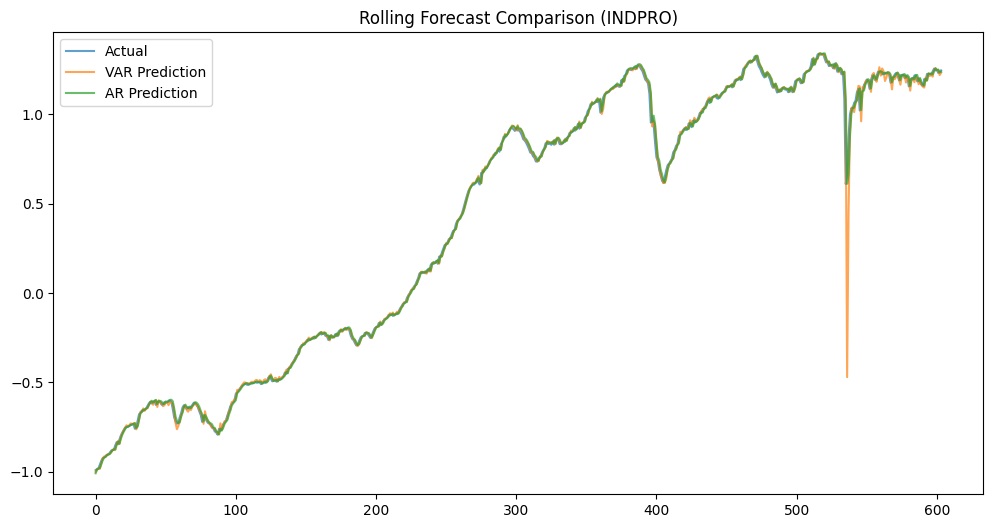

In [22]:
plt.figure(figsize=(12,6))

plt.plot(actual_vals, label='Actual', alpha=0.7)
plt.plot(var_preds, label='VAR Prediction', alpha=0.7)
plt.plot(ar_preds, label='AR Prediction', alpha=0.7)

plt.legend()
plt.title("Rolling Forecast Comparison (INDPRO)")
plt.show()

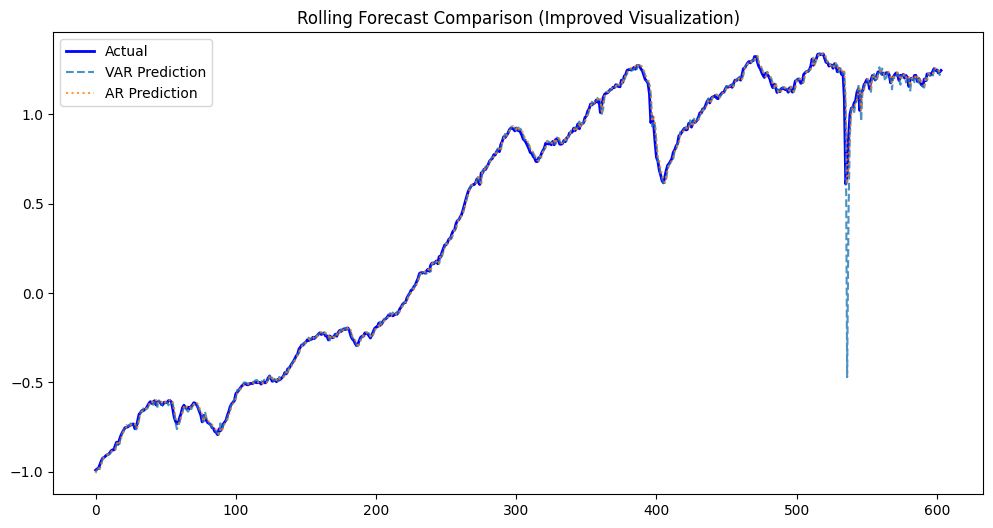

In [23]:
plt.figure(figsize=(12,6))

plt.plot(actual_vals, label='Actual', linewidth=2, color='blue')
plt.plot(var_preds, label='VAR Prediction', linestyle='--', alpha=0.8)
plt.plot(ar_preds, label='AR Prediction', linestyle=':', alpha=0.8)

plt.legend()
plt.title("Rolling Forecast Comparison (Improved Visualization)")
plt.show()

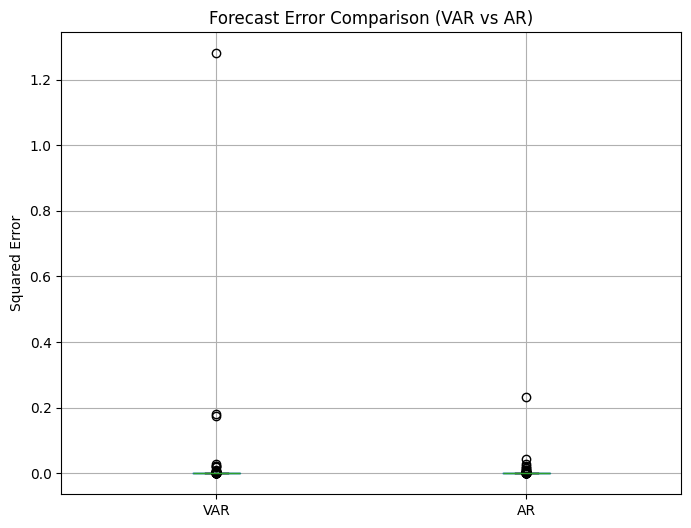

In [24]:
# Create DataFrame of squared errors
import pandas as pd

error_df = pd.DataFrame({
    'VAR': var_errors,
    'AR': ar_errors
})

# Boxplot
plt.figure(figsize=(8,6))
error_df.boxplot()

plt.title("Forecast Error Comparison (VAR vs AR)")
plt.ylabel("Squared Error")
plt.show()

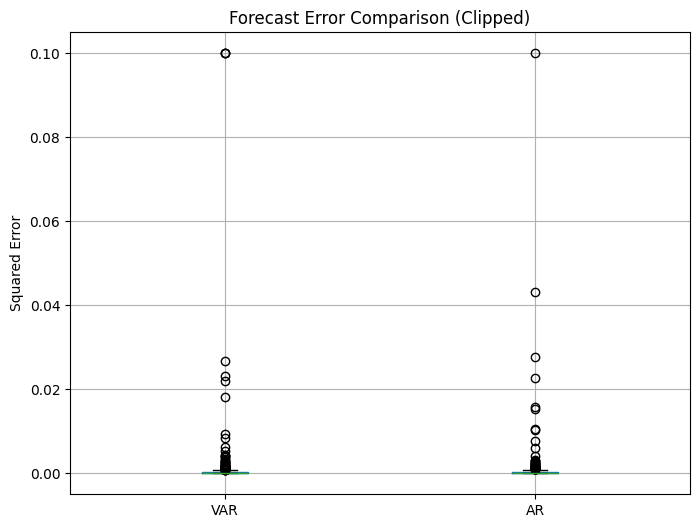

In [25]:
plt.figure(figsize=(8,6))

# Clip extreme values for better visualization
error_df_clipped = error_df.clip(upper=0.1)

error_df_clipped.boxplot()

plt.title("Forecast Error Comparison (Clipped)")
plt.ylabel("Squared Error")
plt.show()

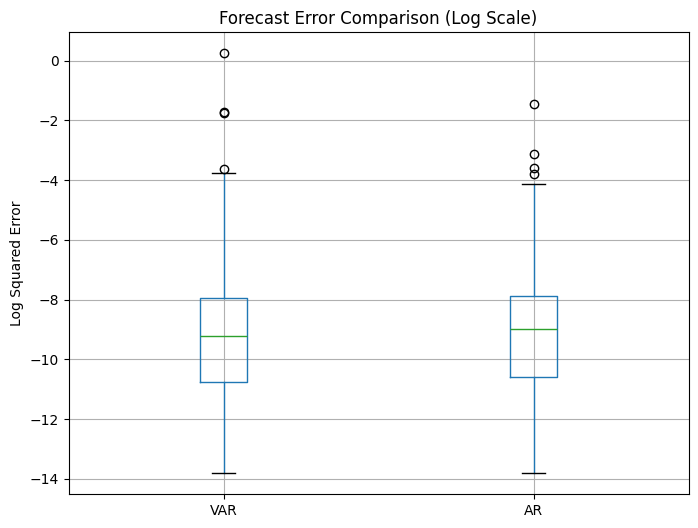

In [26]:
plt.figure(figsize=(8,6))

# Add small value to avoid log(0)
error_df_log = np.log(error_df + 1e-6)

error_df_log.boxplot()

plt.title("Forecast Error Comparison (Log Scale)")
plt.ylabel("Log Squared Error")
plt.show()

#### Section Summary:

- We used a forecast approach to match the original papers methodology. This approach simulates real-time forecasting by updating the training data and making one-step-ahead predictions.

- We evaluated model performance using Root Mean Squared Forecast Error (RMSFE). Here are the results:

- VAR RMSFE = 0.0566

- AR RMSFE = 0.0306

- RMSFE Ratio (VAR / AR) = 1.85

- When the RMSFE ratio is greater than 1 it means the VAR model did not perform well as the AR model in rolling forecasting. The VAR model did worse than the AR model.

#### Reproducibility Insight:

- This result is different from our static evaluation, where VAR performed better than AR. This difference shows how model performance can change based on the evaluation method used.

- The original paper used rolling forecasts which're more realistic but also harder to implement. The difference, between rolling results shows how different experimental setups can lead to different conclusions. This highlights the challenges of reproducing results.

### Section 8: Comparison

- We compared how well the AR model and the VAR model work under test conditions. We wanted to see which one is more accurate and how different ways of testing affect the results.

- First we split the data into a training set and a test set. The VAR model did better than the AR model with an error rate (0.170 vs 0.292). This makes sense because VAR looks at economic factors and how they relate to each other. The AR model only looks at values of one thing so it's more limited.

- When we tested the models in a way that simulates real life. By retraining them at each step and making short-term predictions. The results changed a lot. The AR model did better than the VAR model with an error rate (0.0306 vs 0.0566). This shows that VAR didn't do well as AR in this test.

- This change in results shows that how well a model works depends on how you test it. VAR does well when its trained on a lot of data once. It gets less stable when its retrained on smaller changing datasets. We saw this in the prediction plots, where VAR sometimes made predictions while AR was more consistent.

- Some choices we made when setting up the models affected the results. We had to use a few key economic indicators for VAR because it was too slow to use all the data. This might have made VAR less effective because it couldn't see the economic picture.

- We also made choices about how to handle missing data like filling in missing values. The paper didn't say how to do this so we had to make some guesses. These guesses can affect how the models work and what they find.

- Another important choice was how past values to use. We chose 3 based on some tests but this might not be the best choice for all time periods. This could be another reason why VARs results varied.

- Overall the results show that even if you can repeat the steps of a study, small differences in how you do things can lead to different conclusions. This means that reproducing results in data science isn't about using the same models. Its also about doing everything exactly the same way.

- These findings reinforce a takeaway of this project: getting the same results again is hard and even small differences, in how you handle data set up models or test them can lead to very different conclusions.

### Section 9: Reproducibility Challenges

- We tried to repeat the results of a research paper but it was not easy. We faced practical and methodological problems. These problems show that it is hard to repeat data science results even when we have the data and general method.

- One big problem was that we could not access the computer code. The paper explains the models and evaluation methods in a way but it does not give detailed information about the exact steps used. So we had to make some assumptions about data preparation, model settings and other things. For instance the paper does not say how to handle missing data so we used techniques like interpolation and filling in missing values.

- Another challenge was the dataset. The FRED-MD dataset is public. It gets updated sometimes. The version we used may not be the same as the one used in the original study. Even small changes in the data can affect how well the model works.

- We also had problems with computer power. The original paper uses variables (over 100) but we only used five variables for our model. We did this to make sure the model was stable and did not take long to run. However using variables might have affected how well the model worked.

- The rolling forecast method was also tricky to implement. The paper describes the idea, but not the exact steps. So we made some assumptions about how to do it which might be different from the approach.

- The model was also sensitive to some things. The VAR model in particular is sensitive to the number of variables how past values to use and how to scale the data. Even though we chose the number of values using statistical tests it might not be the best choice for all time periods. This made the VAR predictions unstable.

- Lastly differences in how we measured errors and implemented things might have contributed to results. We used RMSFE like the paper. Small differences in how we calculated errors can lead to different outcomes.

- Overall these challenges show that reproducing data science results is not about having access, to data and models. It also requires documentation, clear methodology and consistent experimental setup. Without these things it is hard to repeat results and we might get different outcomes like we did in this project.

### Section 10: Ethical Considerations

- Data science is really connected to being responsible especially when it comes to making sure that the things we find out from our research are clear and easy to understand and that we can get the results again if we try. If other people cannot check our results for themselves it makes us wonder if they are really true and if we can trust them.

- When I was working on this project I had a lot of trouble trying to get the results as the people who wrote the original paper. I had to deal with things like not having all the details about how they did things not being sure about the steps they took to get their data ready and having to make some guesses when I was building my models. These kinds of problems can lead to results, which shows how important it is to be clear and open about what we are doing.

- The paper also talks about using language models, which brings up even more concerns about what is right and wrong. These models are often trained on sets of data that we do not know much about which makes it hard to know if some of the data was not supposed to be used or if the tests were fair. This lack of clarity can make people not trust the results that are being reported.

- Overall this project shows that getting the results is not just a technical problem, but also a matter of doing what is right. We have to make sure that our data, code and methods are available to everyone and that we document everything clearly so that we can keep peoples trust and be fair and honest in data science.